In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data import load_data

plt.rcParams['font.family'] = 'DejaVu Sans Mono'

In [2]:
df = load_data()

In [6]:
fd = df.transpose().iloc[3:]

In [10]:
import itertools

dist_mat = np.zeros((fd.shape[0], fd.shape[0]))
for i, j in itertools.combinations(range(fd.shape[0]), 2):
    dist_mat[i, j] = (fd.iloc[i] != fd.iloc[j]).sum()
    dist_mat[j, i] = dist_mat[i, j]


c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\umap\umap_.py:1780: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


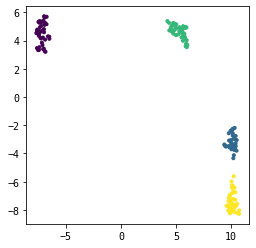

In [38]:
from umap import UMAP
from sklearn.cluster import KMeans

umap = UMAP(
    random_state=42,
    metric='precomputed'
)
umap.fit(dist_mat)
reduced = umap.transform(dist_mat)
k_means = KMeans(n_clusters=4)
k_means.fit(reduced)

plt.figure(figsize=(4, 4))
plt.scatter(
    *reduced.T, 
    s=9.,
    c=k_means.labels_
)
plt.show(); plt.close()

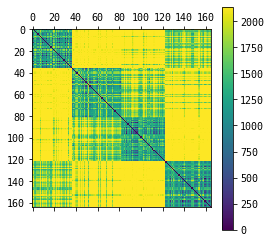

In [37]:
sorter = np.argsort(k_means.labels_)
plt.colorbar(
    plt.matshow(dist_mat[sorter][:, sorter])
)

c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\manifold\_t_sne.py:691: FutureWarning: 'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.
  warnings.warn(


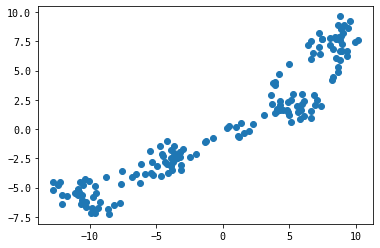

In [32]:
from sklearn.manifold import TSNE

tsne = TSNE(
    random_state=42,
    metric='precomputed'
)
plt.scatter(*tsne.fit_transform(dist_mat).T)
plt.show(); plt.close()

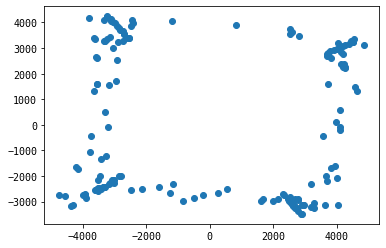

In [34]:
from sklearn.manifold import Isomap

isomap = Isomap(
    metric='precomputed'
)
plt.scatter(*isomap.fit_transform(dist_mat).T)
plt.show(); plt.close()